# Eder Bootstrap Consensus Tree — Demo

This notebook demonstrates the `eder_bct` and `plot_bct` functions
using synthetic data with 5 distinct clusters.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

from bdi import eder_bct, plot_bct
from bdi.metrics import cosine

import mpl_fontkit as fk

# Set up Roboto Condensed font
# fk.install("Roboto Condensed")
fk.install("Story Script")

Font name: `Story Script`


In [2]:
import sys

print(sys.executable)
import bdi.bct

print(bdi.bct.__file__)

/Users/ben/venv/py314/bin/python
/Users/ben/code/bdi/bdi/bct/__init__.py


## Generate Synthetic Data

5 clusters with distinct feature profiles, 30 nodes each.

In [3]:
rng = np.random.default_rng(42)
n_per_cluster = 30
n_features = 20

centers = [
    np.zeros(n_features),
    np.ones(n_features) * 2,
    np.ones(n_features) * 4,
    np.concatenate([np.ones(n_features // 2) * 3, np.zeros(n_features // 2)]),
    np.concatenate([np.zeros(n_features // 2), np.ones(n_features // 2) * 3]),
]

cluster_names = ["Alpha", "Beta", "Gamma", "Delta", "Epsilon"]

X_parts = []
y = []
work_names = []
for i, (center, name) in enumerate(zip(centers, cluster_names)):
    X_parts.append(rng.normal(center, 0.6, (n_per_cluster, n_features)))
    y.extend([f"{name} - {j}" for j in range(n_per_cluster)])
    work_names.extend([name] * n_per_cluster)

X = pd.DataFrame(np.vstack(X_parts))
ss = StandardScaler()
X = pd.DataFrame(ss.fit_transform(X), columns=[f"f{i}" for i in range(n_features)])

print(f"Data: {X.shape[0]} nodes, {X.shape[1]} features")
print(f"Clusters: {len(cluster_names)}")

Data: 150 nodes, 20 features
Clusters: 5


## Run Eder BCT

In [4]:
graph_trim = eder_bct(
    X,
    y,
    n=500,
    keep_pct=0.2,
    feats_pct=0.35,
    rng=np.random.default_rng(42),
    metric=cosine,
)
print(f"Edges: {len(graph_trim)}")
graph_trim.head()

Edges: 1364


,from,to,weight
6634,Gamma - 4,Gamma - 26,1226
6328,Gamma - 22,Gamma - 12,899
2654,Beta - 25,Beta - 21,820
609,Alpha - 25,Alpha - 19,816
5808,Epsilon - 9,Epsilon - 13,801


In [5]:
import importlib

importlib.reload(bdi.bct)

<module 'bdi.bct' from '/Users/ben/code/bdi/bdi/bct/__init__.py'>

## Plot — Default Settings

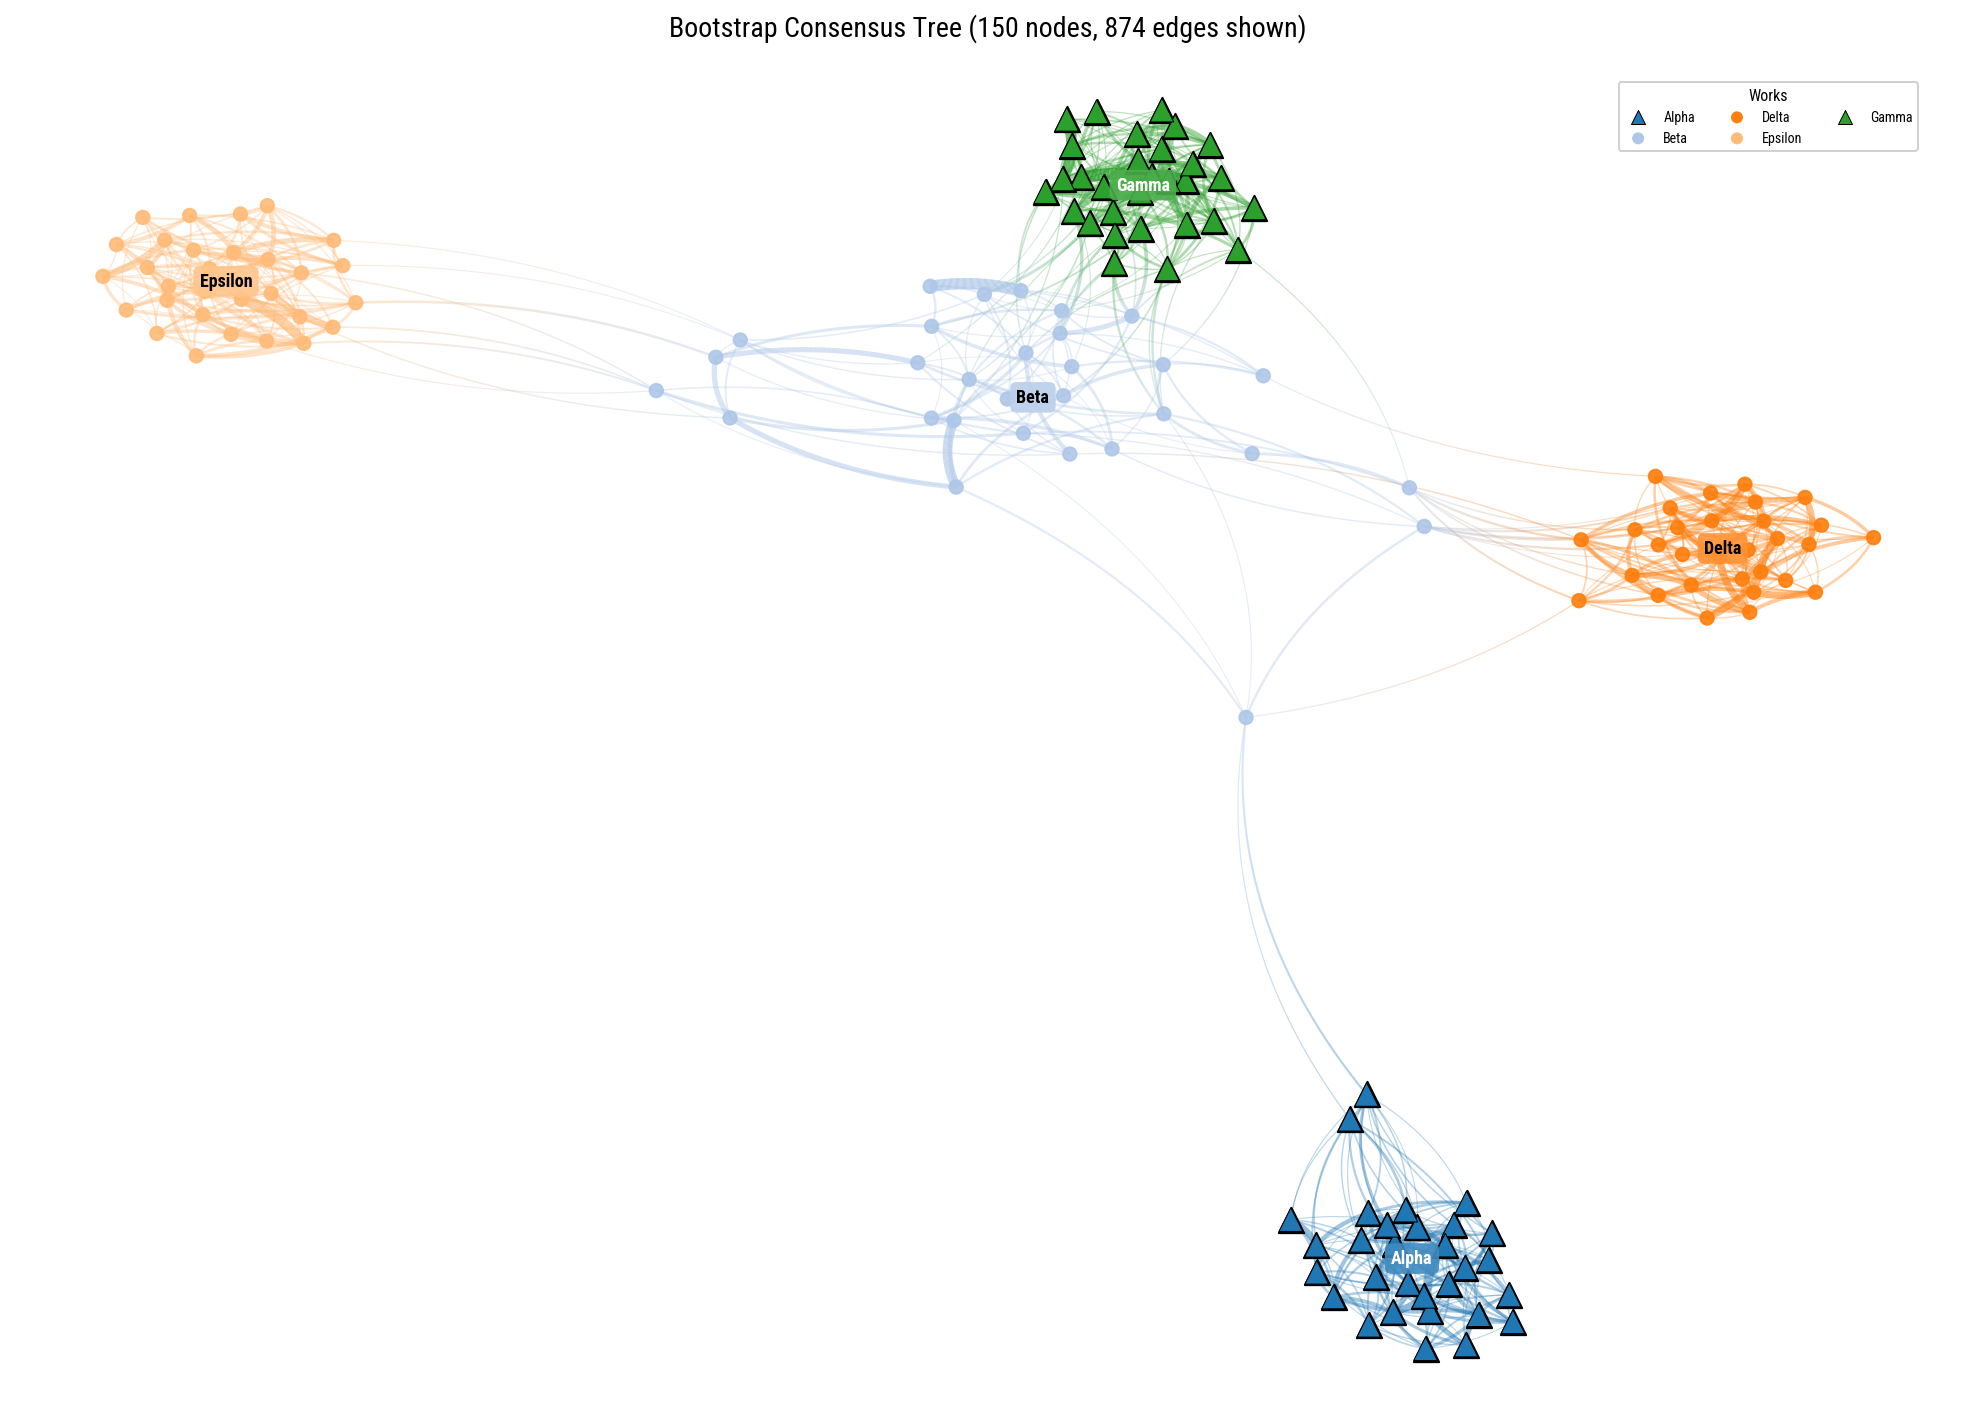

In [6]:
fig, ax = plot_bct(
    graph_trim,
    work_names,
    y,
    highlight_works=["Alpha", "Gamma"],
    figsize=(14, 10),
    min_weight=80,
    layout_k=0.3,
    curvature=0.15,
    edge_width_range=(0.5, 6.0),
)
plt.show()

## Post-hoc Customization

Since `plot_bct` returns `(fig, ax)`, you can customize the plot
before calling `plt.show()`:

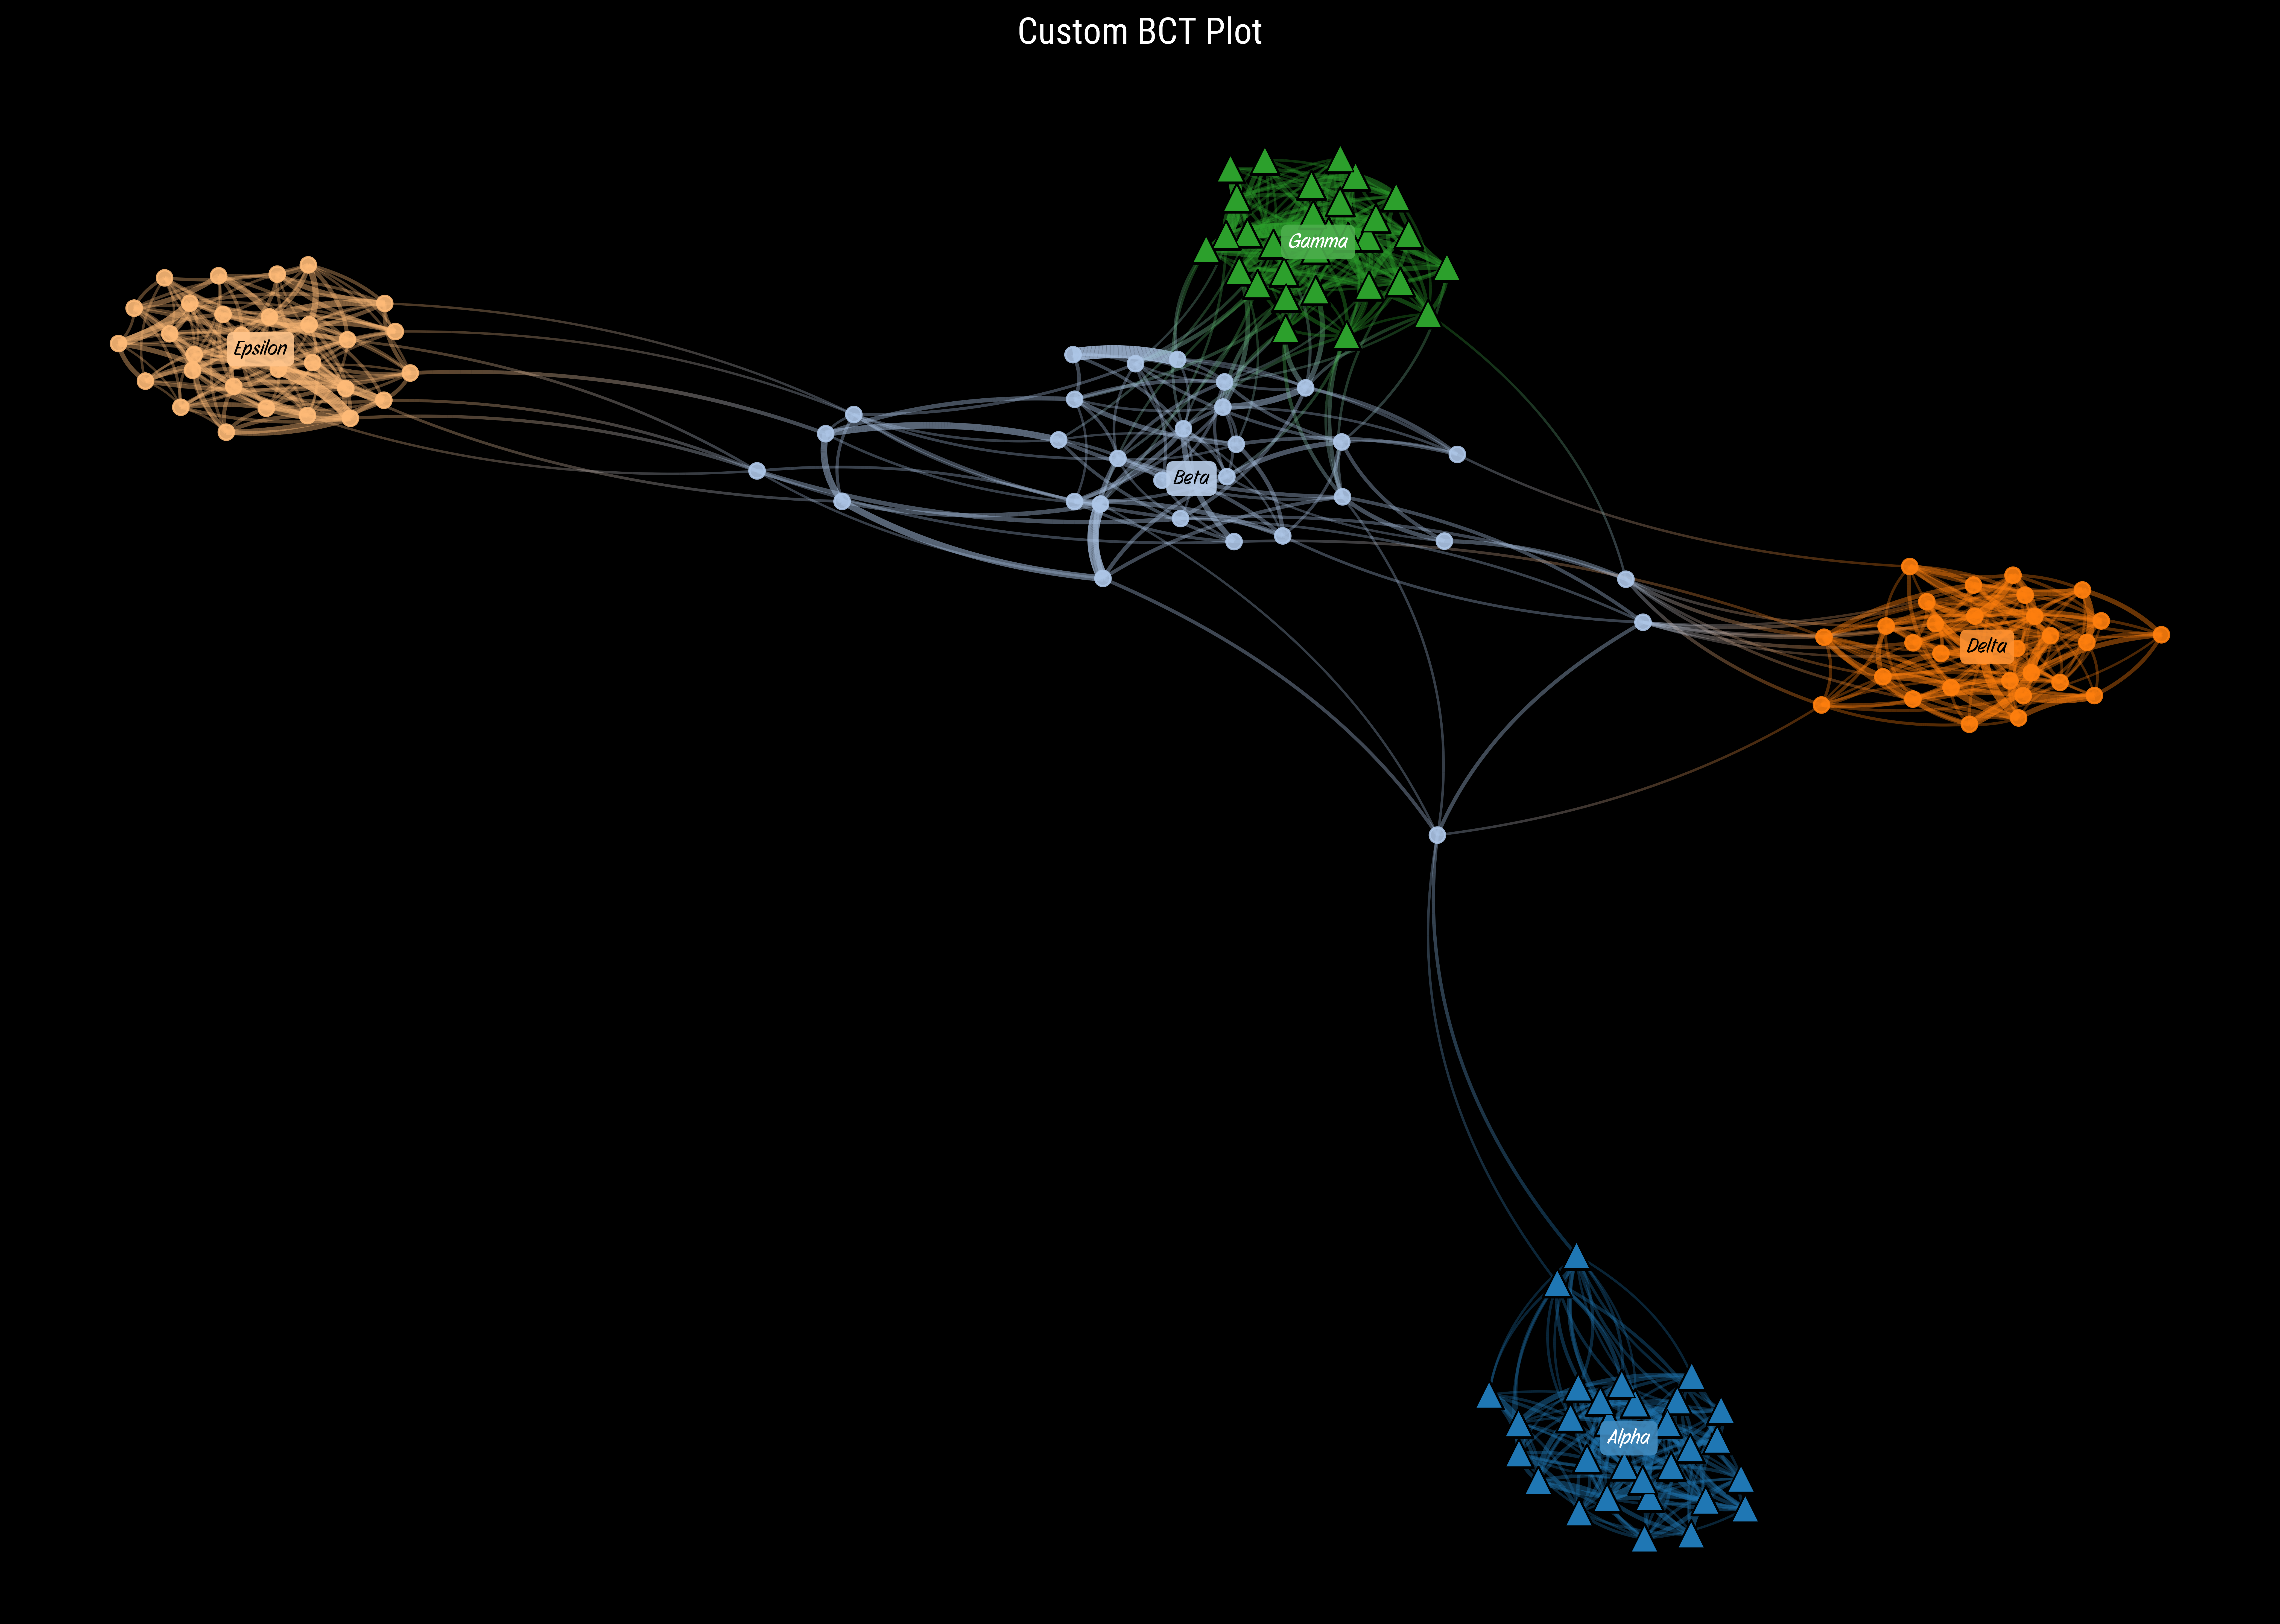

In [7]:
fig, ax = plot_bct(
    graph_trim,
    work_names,
    y,
    highlight_works=["Alpha", "Gamma"],
    figsize=(14, 10),
    min_weight=80,
    layout_k=0.3,
    curvature=0.15,
    edge_width_range=(1, 6.0),
    dpi=600,
)

# Remove legend
ax.legend().remove()

# Change background
fig.set_facecolor("#000000")

# Change label text
for text in ax.texts:
    text.set_fontweight("normal")
    text.set_family("Story Script")

# Add custom title
ax.set_title(
    "Custom BCT Plot", fontsize=16, fontfamily="Roboto Condensed", color="white", pad=20
)

plt.tight_layout()
plt.savefig("bct_demo_custom.png", dpi=300, bbox_inches="tight")
plt.show()

## Parameter Exploration

Try different layout and edge parameters:

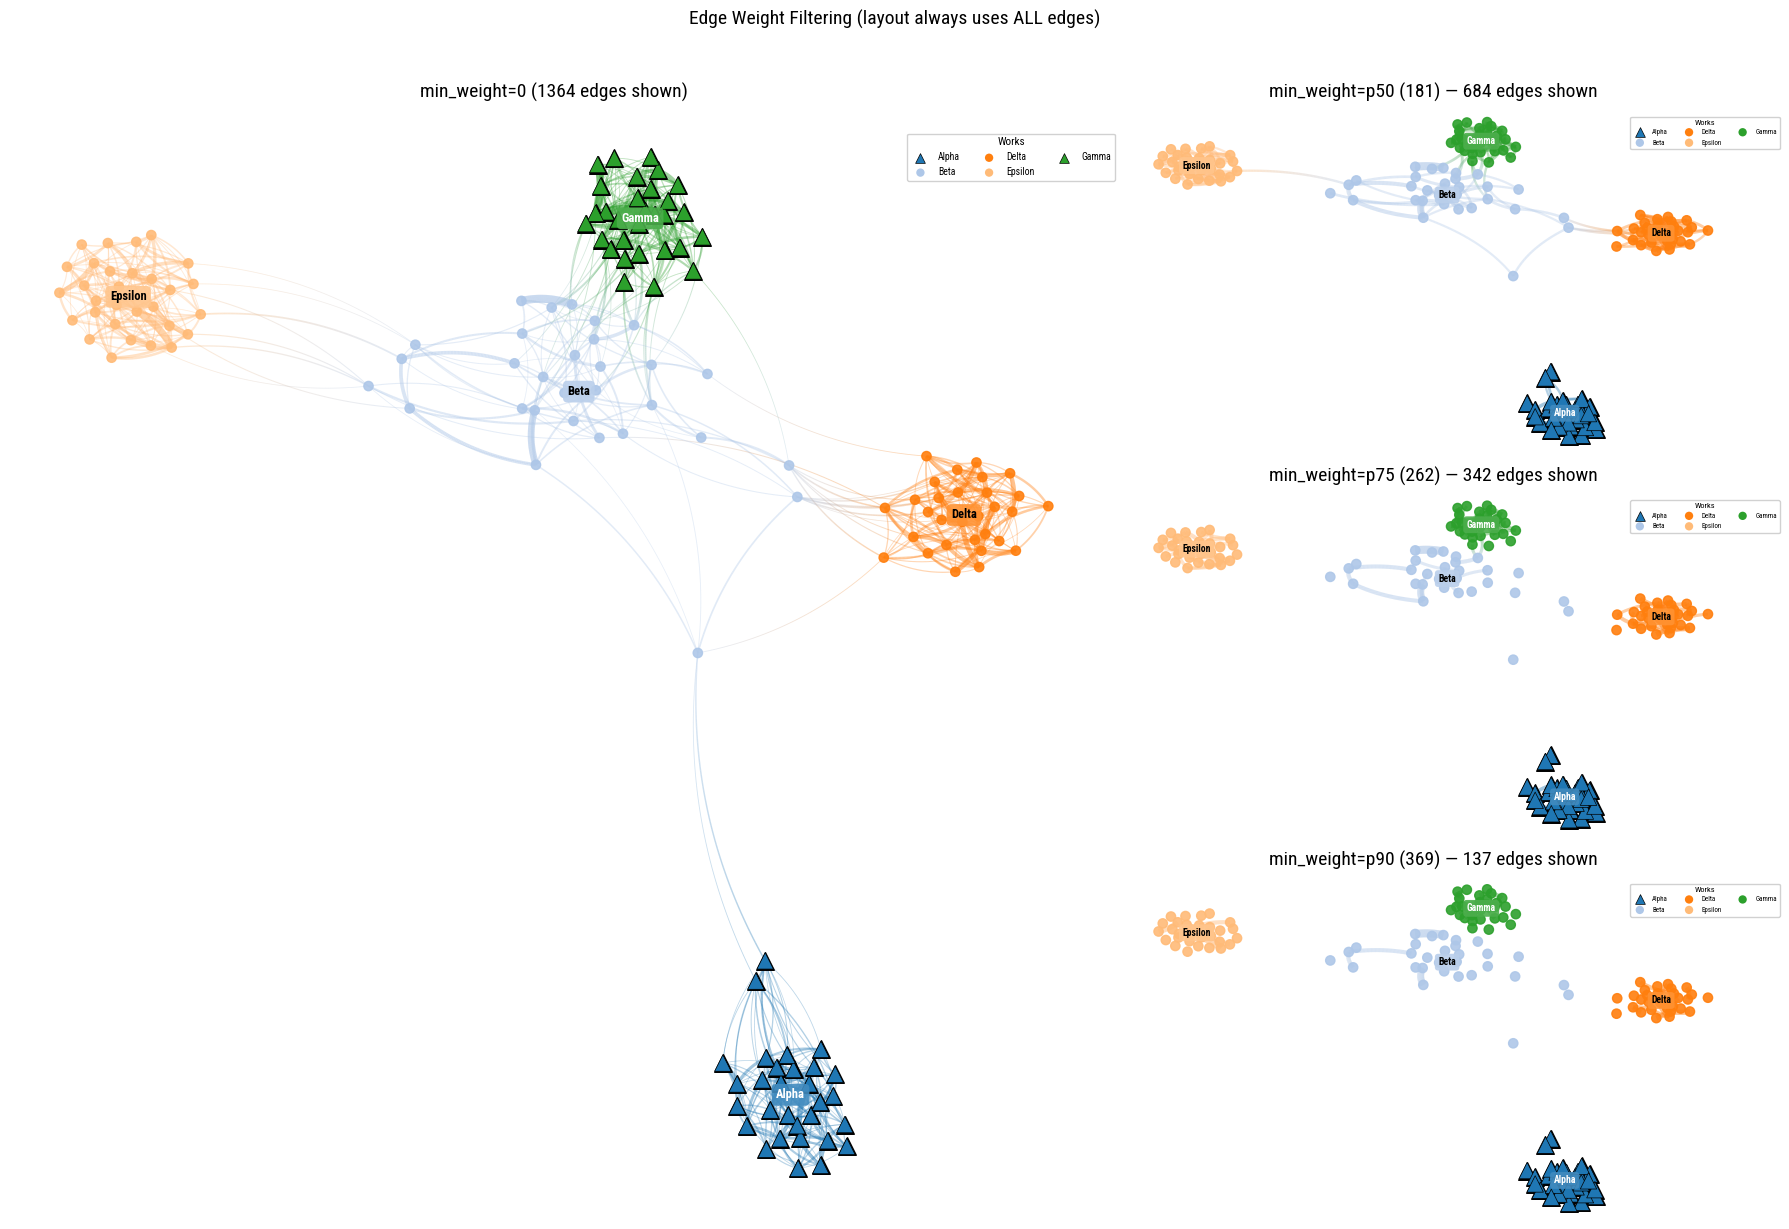

In [8]:
# subplot_mosaic lets us create complex layouts with a string spec.
# "A" is the large left panel; "B", "C", "D" are the three right panels.
fig, axes = plt.subplot_mosaic(
    [
        ["A", "B"],
        ["A", "C"],
        ["A", "D"],
    ],
    figsize=(18, 12),
    gridspec_kw={"width_ratios": [1.8, 1]},
)

# Compute weight percentiles for consistent comparison
all_weights = graph_trim["weight"].values
p25, p50, p75 = np.percentile(all_weights, [25, 50, 75])

# Large default plot on the left
plot_bct(
    graph_trim,
    work_names,
    y,
    highlight_works=["Alpha", "Gamma"],
    ax=axes["A"],
    min_weight=0,
    layout_k=0.3,
    curvature=0.15,
    edge_width_range=(0.5, 6.0),
    title=f"min_weight=0 ({len(graph_trim)} edges shown)",
)

# Three comparison plots on the right with increasing min_weight
# Note: node positions are IDENTICAL because layout uses ALL edges.
# Only the visible edge density changes.
for ax_key, pct, label in zip(["B", "C", "D"], [50, 75, 90], ["p50", "p75", "p90"]):
    w = np.percentile(all_weights, pct)
    n_shown = (all_weights >= w).sum()
    plot_bct(
        graph_trim,
        work_names,
        y,
        highlight_works=["Alpha"],
        ax=axes[ax_key],
        min_weight=w,
        layout_k=0.3,
        curvature=0.15,
        edge_width_range=(1, 6.0),
        title=f"min_weight={label} ({w:.0f}) — {n_shown} edges shown",
        legend_fontsize=5,
        label_fontsize=7,
    )

fig.suptitle(
    "Edge Weight Filtering (layout always uses ALL edges)",
    fontsize=14,
    fontfamily="Roboto Condensed",
    y=1.02,
)
plt.tight_layout()
plt.savefig("bct_demo_weight_filtering.png", dpi=200, bbox_inches="tight")
plt.show()